In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print('✅ Imports OK')

✅ Imports OK


In [2]:
caminho = '/kaggle/input/datasets/laveshjadon/ai-impact-on-students/ai_student_impact_dataset (1).csv'
df = pd.read_csv(caminho)

print('Shape:', df.shape)
print('\nColunas:', list(df.columns))
print('\nDistribuição do Target:')
print(df['Burnout_Risk_Level'].value_counts())

Shape: (50000, 16)

Colunas: ['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score', 'Burnout_Risk_Level']

Distribuição do Target:
Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64


In [3]:
df['AI_Ratio']              = df['Weekly_GenAI_Hours'] / (df['Traditional_Study_Hours'] + 1)
df['AI_Dependency_x_Ratio'] = df['Perceived_AI_Dependency'] * df['AI_Ratio']

COLUNAS_NUMERICAS = [
    'Traditional_Study_Hours',
    'Weekly_GenAI_Hours',
    'AI_Ratio',
    'AI_Dependency_x_Ratio',
    'Perceived_AI_Dependency',
    'Pre_Semester_GPA',
    'Post_Semester_GPA',
    'Anxiety_Level_During_Exams',
    'Skill_Retention_Score',
    'Tool_Diversity',
]

COLUNAS_CATEGORICAS = [
    'Major_Category',
    'Year_of_Study',
    'Primary_Use_Case',
    'Prompt_Engineering_Skill',
    'Institutional_Policy',
]

TARGET = 'Burnout_Risk_Level'

cols_num = [c for c in COLUNAS_NUMERICAS if c in df.columns]
cols_cat = [c for c in COLUNAS_CATEGORICAS if c in df.columns]

print('Features numéricas:', cols_num)
print('Features categóricas:', cols_cat)

X = df[cols_num + cols_cat].copy()
y = df[TARGET].copy()

print(f'\nShape X: {X.shape}')

Features numéricas: ['Traditional_Study_Hours', 'Weekly_GenAI_Hours', 'AI_Ratio', 'AI_Dependency_x_Ratio', 'Perceived_AI_Dependency', 'Pre_Semester_GPA', 'Post_Semester_GPA', 'Anxiety_Level_During_Exams', 'Skill_Retention_Score', 'Tool_Diversity']
Features categóricas: ['Major_Category', 'Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Institutional_Policy']

Shape X: (50000, 15)


In [4]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), cols_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_cat)
])

modelo_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        random_state=42
    ))
])

print('✅ Pipeline criado!')

✅ Pipeline criado!


In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(modelo_pipeline, X, y, cv=skf, scoring='accuracy')

print('📊 Validação Cruzada (5-Fold):')
print(f'  Acurácia por fold: {[round(s, 4) for s in scores]}')
print(f'  Média: {scores.mean():.4f}')
print(f'  Desvio padrão: {scores.std():.4f}')

📊 Validação Cruzada (5-Fold):
  Acurácia por fold: [np.float64(0.5391), np.float64(0.5339), np.float64(0.5243), np.float64(0.5463), np.float64(0.531)]
  Média: 0.5349
  Desvio padrão: 0.0074


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

modelo_pipeline.fit(X_train, y_train)
previsoes = modelo_pipeline.predict(X_test)

print('📊 Relatório de Classificação — v2:')
print(classification_report(y_test, previsoes))

📊 Relatório de Classificação — v2:
              precision    recall  f1-score   support

        High       0.65      0.47      0.55      2497
         Low       0.54      0.49      0.51      3274
      Medium       0.48      0.60      0.54      4229

    accuracy                           0.53     10000
   macro avg       0.56      0.52      0.53     10000
weighted avg       0.54      0.53      0.53     10000



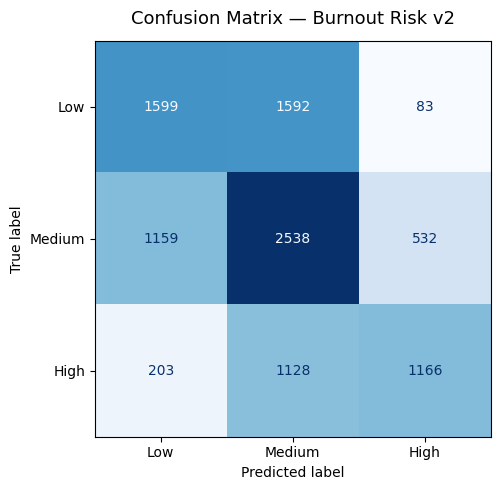

In [7]:
cm = confusion_matrix(y_test, previsoes, labels=['Low', 'Medium', 'High'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Burnout Risk v2', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('confusion_matrix_v2.png', dpi=150)
plt.show()

/tmp/ipykernel_23/2640632059.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x='importance', y='feature', palette='viridis', ax=ax)


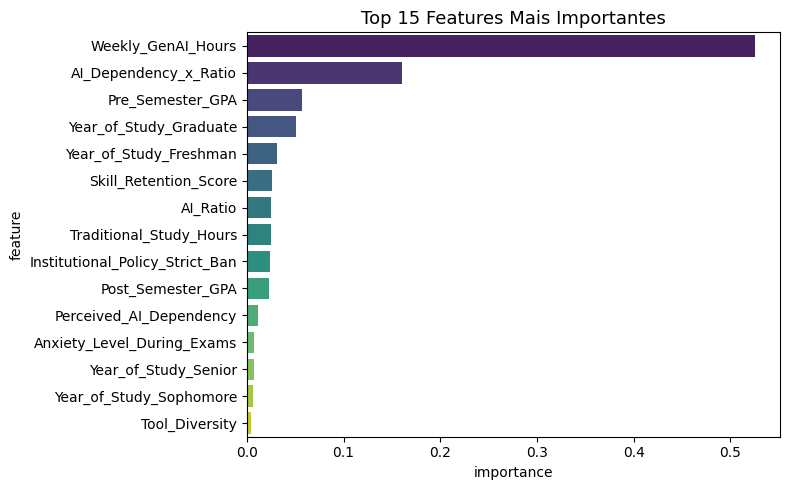

In [8]:
importancias  = modelo_pipeline.named_steps['classifier'].feature_importances_
ohe_names     = modelo_pipeline.named_steps['preprocessor']\
                    .named_transformers_['cat']\
                    .get_feature_names_out(cols_cat).tolist()
feature_names = cols_num + ohe_names

df_imp = pd.DataFrame({'feature': feature_names, 'importance': importancias})\
           .sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_imp, x='importance', y='feature', palette='viridis', ax=ax)
ax.set_title('Top 15 Features Mais Importantes', fontsize=13)
plt.tight_layout()
plt.savefig('feature_importance_v2.png', dpi=150)
plt.show()

In [9]:
joblib.dump(modelo_pipeline, 'modelo_burnout_v2.pkl')

metadados = {
    'colunas_numericas': cols_num,
    'colunas_categoricas': cols_cat,
    'classes': list(modelo_pipeline.classes_),
    'versao': '2.0'
}
with open('model_metadata_v2.json', 'w') as f:
    json.dump(metadados, f, indent=2)

print('✅ Modelo salvo como modelo_burnout_v2.pkl')
print('✅ Metadados salvos como model_metadata_v2.json')

✅ Modelo salvo como modelo_burnout_v2.pkl
✅ Metadados salvos como model_metadata_v2.json
